# Pseudo-activations from model RDMs

Generate synthetic neural activations whose representational geometry is fully specified by a target RDM.
Then run the same decoding pipeline used on real RNN activations to understand what geometry is
sufficient for cross-context value decoding.

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from cxval.vis import STYLE, add_colorbar
from cxval.analysis import (
    compute_model_rdms, compute_neural_rdm, rsa_compare,
    value_decode_within, value_decode_cross, value_gen_matrix,
    binary_value_decode_within, binary_value_decode_cross,
    plot_generalisation_heatmap,
)
plt.style.use(STYLE)

## 1. Task definition

In [105]:
# ── Value matrix (n_stim × n_ctx) ────────────────────────────────────────────
# Edit this to explore different task structures.
# Rows = stimuli, columns = contexts.

# Example: 5-stim, 2-ctx with anchor + swap stimuli
#   anchors (s0, s1): same value across both contexts
#   swaps   (s2, s3): value reverses between contexts
#   mid     (s4):     intermediate value in both contexts
value_matrix = np.array([
    # [1.0, 1.0],   # s0: anchor high
    # [0.0, 0.0],   # s1: anchor low
    [1.0, 0.0],   # s2: swap
    [0.0, 1.0],   # s3: swap
    [0.5, 0.5],   # s4: mid
])

n_stim, n_ctx = value_matrix.shape
contexts  = [f"ctx{c}" for c in range(n_ctx)]
stimuli   = [f"s{s}"   for s in range(n_stim)]

print("Value matrix:")
print(value_matrix)
print(f"\n{n_stim} stimuli, {n_ctx} contexts")

Value matrix:
[[1.  0. ]
 [0.  1. ]
 [0.5 0.5]]

3 stimuli, 2 contexts


## 2. Model RDMs

Three models:
- **Identity**: 0 if same stimulus (regardless of context), 1 otherwise
- **Factorised Value**: |value_i − value_j|, normalised — context-general value coding
- **Conjunctive value**: within each context, encodes value distance; across contexts, fully dissimilar (= 1). Represents context-specific value axes that don't generalise.

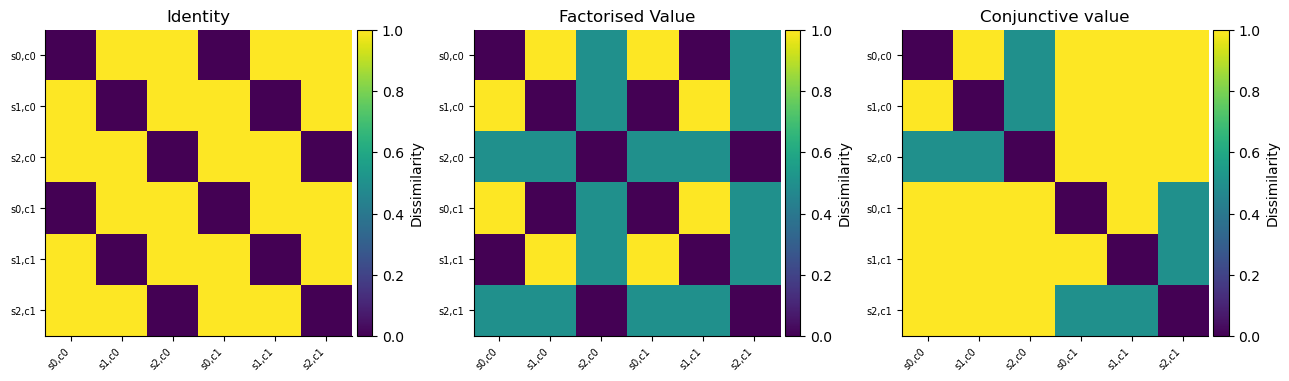

In [106]:
# Conditions ordered context-major (matches compute_neural_rdm convention)
conditions  = [(si, ci) for ci in range(n_ctx) for si in range(n_stim)]
cond_labels = [f"s{si},c{ci}" for si, ci in conditions]
K = len(conditions)

id_rdm, val_rdm = compute_model_rdms(conditions, value_matrix)


def compute_conjunctive_value_rdm(conditions, value_matrix):
    """Context-specific value coding: within-context value distance, cross-context = 1.

    Conditions that share a context are separated by their value difference
    (normalised to [0, 1]); conditions in different contexts are maximally
    dissimilar regardless of value.  A decoder trained in one context will
    therefore not generalise to the other.
    """
    n_cond   = len(conditions)
    all_vals = [float(value_matrix[si, ci]) for si, ci in conditions]
    max_diff = max(abs(v1 - v2) for v1 in all_vals for v2 in all_vals)
    rdm      = np.ones((n_cond, n_cond))
    for i, (si, ci) in enumerate(conditions):
        for j, (sj, cj) in enumerate(conditions):
            if ci == cj:
                diff = abs(float(value_matrix[si, ci]) - float(value_matrix[sj, cj]))
                rdm[i, j] = diff / max_diff if max_diff > 0 else 0.0
    return rdm


conj_rdm = compute_conjunctive_value_rdm(conditions, value_matrix)

model_rdms = {"Identity": id_rdm, "Factorised Value": val_rdm, "Conjunctive value": conj_rdm}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (title, rdm) in zip(axes, model_rdms.items()):
    vm = max(np.nanmax(rdm), 0.01)
    im = ax.imshow(rdm, cmap="viridis", vmin=0, vmax=vm, aspect="equal")
    ax.set_xticks(range(K)); ax.set_xticklabels(cond_labels, fontsize=7, rotation=45, ha="right")
    ax.set_yticks(range(K)); ax.set_yticklabels(cond_labels, fontsize=7)
    ax.set_title(title)
    add_colorbar(ax, im, label="Dissimilarity")
plt.tight_layout()
plt.show()

## 3. Pseudo-activation generation

For a target RDM, convert to a similarity (covariance) matrix $S = 1 - \text{RDM}_{\text{norm}}$,
project to PSD, then draw each neuron's condition-responses from $\mathcal{N}(0, S)$.
This guarantees the expected neural RDM matches the target.

Trials: each condition gets `n_trials_per_cond` independent draws from
$\mathcal{N}(\mu_k,\, \sigma^2 I)$ where $\mu_k$ is the condition mean.

In [107]:
def rdm_to_psd_similarity(rdm):
    """Normalise RDM to [0,1] then convert to similarity; project to PSD."""
    mx = rdm.max()
    S  = 1.0 - (rdm / mx if mx > 0 else rdm)
    vals, vecs = np.linalg.eigh(S)
    return (vecs * np.clip(vals, 0, None)) @ vecs.T


def build_pseudo_act_dict(value_matrix, rdm, n_neurons=300,
                          n_trials_per_cond=80, noise_std=0.3, seed=42):
    """Build an act_dict whose representational geometry matches *rdm*.

    Conditions are ordered context-major to match compute_neural_rdm.
    Each pseudo-neuron's condition-mean vector is drawn from N(0, S),
    then per-trial Gaussian noise (noise_std * I) is added.

    Total trials = n_conditions * n_trials_per_cond.
    stim_hidden shape: (n_trials, 1, n_neurons)  [single timestep].
    """
    rng = np.random.default_rng(seed)
    n_stim, n_ctx = value_matrix.shape
    conditions    = [(si, ci) for ci in range(n_ctx) for si in range(n_stim)]
    K             = len(conditions)

    S = rdm_to_psd_similarity(rdm)
    S += 1e-8 * np.eye(K)
    L = np.linalg.cholesky(S)      # (K, K)

    Z          = rng.standard_normal((K, n_neurons))
    cond_means = L @ Z              # (K, n_neurons)

    n_trials = K * n_trials_per_cond
    stim_arr = np.empty(n_trials, dtype=int)
    ctx_arr  = np.empty(n_trials, dtype=int)
    hidden   = np.empty((n_trials, 1, n_neurons))

    for k, (si, ci) in enumerate(conditions):
        sl = slice(k * n_trials_per_cond, (k + 1) * n_trials_per_cond)
        stim_arr[sl]   = si
        ctx_arr[sl]    = ci
        noise          = rng.standard_normal((n_trials_per_cond, n_neurons)) * noise_std
        hidden[sl, 0]  = cond_means[k] + noise

    return {
        "context":       ctx_arr,
        "stimulus":      stim_arr,
        "stim_hidden":   hidden,
        "reward_hidden": hidden,
    }


def get_condition_means(act, value_matrix):
    """Return (K, n_neurons) condition-mean activation matrix."""
    n_stim, n_ctx = value_matrix.shape
    conditions = [(si, ci) for ci in range(n_ctx) for si in range(n_stim)]
    hidden   = act["stim_hidden"][:, 0, :]   # (n_trials, n_neurons)
    stim_arr = act["stimulus"]
    ctx_arr  = act["context"]
    means = np.full((len(conditions), hidden.shape[1]), np.nan)
    for k, (si, ci) in enumerate(conditions):
        mask = (stim_arr == si) & (ctx_arr == ci)
        means[k] = hidden[mask].mean(0)
    return means, conditions

## 4. Sanity check: recover target RSA

Generate activations from each pure model RDM and verify that the neural RDM
computed from the pseudo-activations matches the target.

In [108]:
for label, target_rdm in [("Identity", id_rdm), ("Factorised Value", val_rdm), ("Conjunctive", conj_rdm)]:
    act = build_pseudo_act_dict(value_matrix, target_rdm)
    neural_rdm, _ = compute_neural_rdm(act, period="stim")
    rsa = rsa_compare(neural_rdm, {"identity": id_rdm, "value": val_rdm, "conjunctive": conj_rdm})
    print(f"{label:20s} target → "
          f"identity r={rsa['identity']:+.3f}  "
          f"value r={rsa['value']:+.3f}  "
          f"conjunctive r={rsa['conjunctive']:+.3f}")

Identity             target → identity r=+0.694  value r=-0.163  conjunctive r=-0.489
Factorised Value     target → identity r=-0.193  value r=+0.908  conjunctive r=+0.000
Conjunctive          target → identity r=-0.039  value r=-0.281  conjunctive r=+0.768


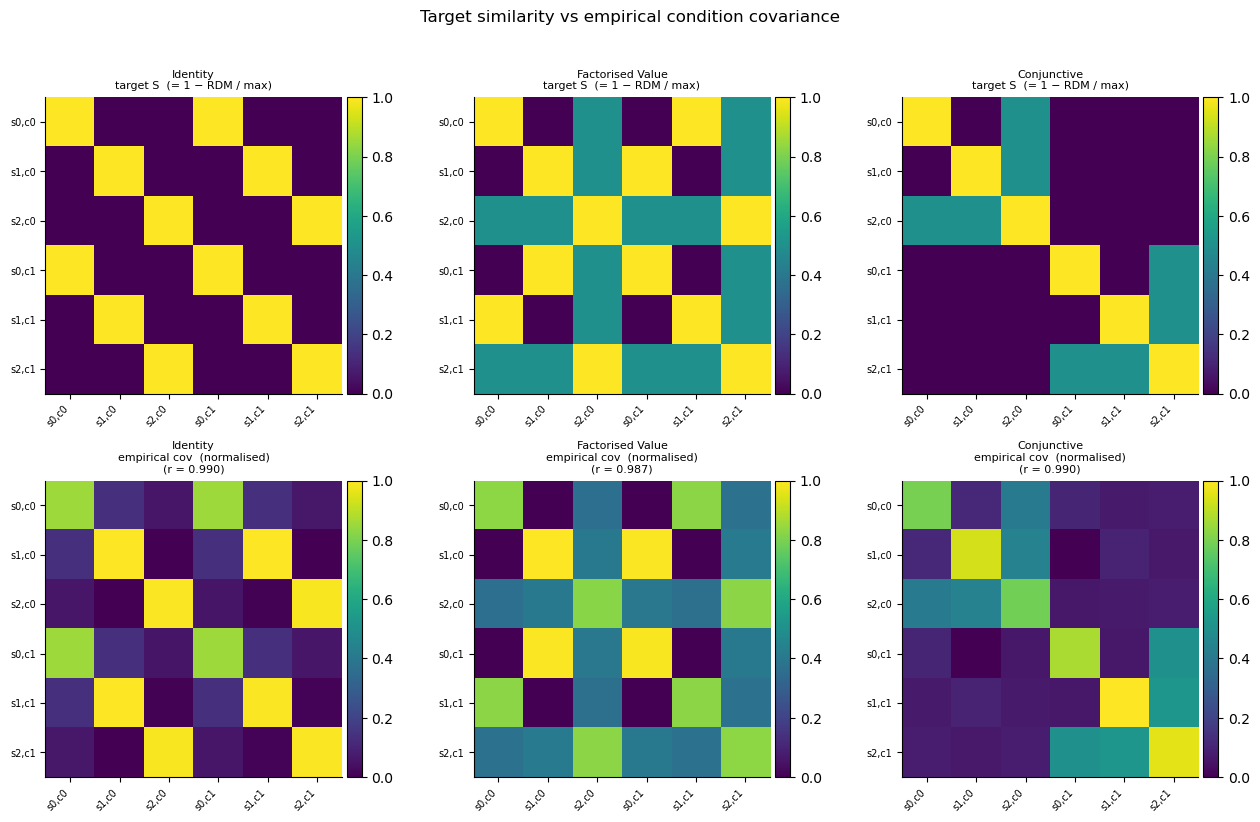

In [109]:
# Visual sanity check: target similarity S vs empirical condition covariance
# The condition means are drawn from N(0, S), so cond_means @ cond_means.T / n_neurons ≈ S.
_check_rdms = [("Identity", id_rdm), ("Factorised Value", val_rdm), ("Conjunctive", conj_rdm)]

def _norm01(m):
    lo, hi = m.min(), m.max()
    return (m - lo) / (hi - lo + 1e-12)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for col, (label, target_rdm) in enumerate(_check_rdms):
    act_chk = build_pseudo_act_dict(value_matrix, target_rdm, seed=42)
    means, _ = get_condition_means(act_chk, value_matrix)  # (K, n_neurons)

    # Target similarity: S = 1 - RDM_norm
    mx = target_rdm.max()
    S_target = 1.0 - (target_rdm / mx if mx > 0 else target_rdm)

    # Empirical condition covariance: cond_means @ cond_means.T / n_neurons
    S_emp = (means @ means.T) / means.shape[1]

    r_match = np.corrcoef(S_target.ravel(), S_emp.ravel())[0, 1]

    for row, (mat, row_label) in enumerate([
        (S_target,    "target S  (= 1 − RDM / max)"),
        (_norm01(S_emp), "empirical cov  (normalised)"),
    ]):
        ax = axes[row, col]
        im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1, aspect="equal")
        ax.set_xticks(range(K))
        ax.set_xticklabels(cond_labels, fontsize=7, rotation=45, ha="right")
        ax.set_yticks(range(K))
        ax.set_yticklabels(cond_labels, fontsize=7)
        title = f"{label}\n{row_label}"
        if row == 1:
            title += f"\n(r = {r_match:.3f})"
        ax.set_title(title, fontsize=8)
        add_colorbar(ax, im)

fig.suptitle("Target similarity vs empirical condition covariance", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

n_neurons         = 300
n_trials_per_cond = 80
noise_std         = 0.3

_pca_rdms = [("Identity", id_rdm), ("Factorised Value", val_rdm), ("Conjunctive", conj_rdm)]
_val_norm = Normalize(0, 1)
_val_cmap = plt.cm.RdYlGn

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (label, target_rdm) in zip(axes, _pca_rdms):
    act_pca       = build_pseudo_act_dict(value_matrix, target_rdm,
                                          n_neurons=n_neurons,
                                          n_trials_per_cond=n_trials_per_cond,
                                          noise_std=noise_std, seed=42)
    means, _conds = get_condition_means(act_pca, value_matrix)   # (K, n_neurons)

    pca    = PCA(n_components=2)
    coords = pca.fit_transform(means)                             # (K, 2)
    var    = pca.explained_variance_ratio_

    # dashed lines connecting same stimulus across contexts (bottom layer)
    for si in range(n_stim):
        pts = [coords[k] for k, (s, c) in enumerate(_conds) if s == si]
        if len(pts) == 2:
            ax.plot([pts[0][0], pts[1][0]], [pts[0][1], pts[1][1]],
                    color="gray", lw=0.8, ls="--", zorder=1)

    # ctx1: larger filled squares drawn first — corners poke out from behind circles
    for k, (si, ci) in enumerate(_conds):
        if ci != 1:
            continue
        color = _val_cmap(_val_norm(float(value_matrix[si, ci])))
        ax.scatter(coords[k, 0], coords[k, 1],
                   facecolors=color, edgecolors="black",
                   marker="s", s=280, linewidths=0.8, zorder=2)
        ax.annotate(f"s{si}", (coords[k, 0], coords[k, 1]),
                    xytext=(-6, -10), textcoords="offset points",
                    fontsize=7, ha="right", va="top")

    # ctx0: smaller filled circles drawn on top
    for k, (si, ci) in enumerate(_conds):
        if ci != 0:
            continue
        color = _val_cmap(_val_norm(float(value_matrix[si, ci])))
        ax.scatter(coords[k, 0], coords[k, 1],
                   facecolors=color, edgecolors="black",
                   marker="o", s=130, linewidths=0.8, zorder=3)
        ax.annotate(f"s{si}", (coords[k, 0], coords[k, 1]),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=7, ha="left", va="bottom")

    ax.axhline(0, color="lightgray", lw=0.5)
    ax.axvline(0, color="lightgray", lw=0.5)
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% var)", fontsize=9)
    ax.set_title(label)

# context legend
_ctx_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="black", markeredgewidth=0.8, markersize=9,  label="ctx0  (label: top-right)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="black", markeredgewidth=0.8, markersize=11, label="ctx1  (label: bottom-left)"),
]
axes[0].legend(handles=_ctx_handles, fontsize=8, loc="best")

# colorbar below
fig.subplots_adjust(bottom=0.18)
cax = fig.add_axes([0.15, 0.04, 0.55, 0.03])
cb  = fig.colorbar(ScalarMappable(cmap=_val_cmap, norm=_val_norm),
                   cax=cax, orientation="horizontal")
cb.set_label("Value")

fig.suptitle(
    f"PCA of condition means  ·  {n_neurons} neurons  ·  noise={noise_std}\n"
    "Dashed lines connect the same stimulus across contexts",
    y=1.03,
)
plt.show()

## 5. Decoding analysis on a single geometry

`alpha` controls the mixture between the identity and value model RDMs.
Set `target_rdm` directly to `conj_rdm` to test the conjunctive model.
- `alpha = 0`: pure identity geometry
- `alpha = 1`: pure value geometry

In [110]:
# ── Parameters ────────────────────────────────────────────────────────────────
alpha             = 1.0    # mixture weight: 0 = identity, 1 = value
n_neurons         = 300
n_trials_per_cond = 80
noise_std         = 0.3
pooling           = "average"
n_folds           = 5

def _norm(rdm):
    mx = rdm.max()
    return rdm / mx if mx > 0 else rdm

# ── Choose target RDM ─────────────────────────────────────────────────────────
# Options: mixed identity/value, or conjunctive:
#   target_rdm = conj_rdm
target_rdm = (1 - alpha) * _norm(id_rdm) + alpha * _norm(val_rdm)

act = build_pseudo_act_dict(
    value_matrix, target_rdm,
    n_neurons=n_neurons, n_trials_per_cond=n_trials_per_cond,
    noise_std=noise_std,
)
print(f"act_dict: {len(act['stimulus'])} trials  "
      f"({len(conditions)} conds × {n_trials_per_cond} trials/cond)  "
      f"stim_hidden shape: {act['stim_hidden'].shape}")

# ── RSA verify ────────────────────────────────────────────────────────────────
neural_rdm, _ = compute_neural_rdm(act, period="stim")
rsa = rsa_compare(neural_rdm, {"identity": id_rdm, "value": val_rdm, "conjunctive": conj_rdm})
print(f"\nRSA: identity r={rsa['identity']:+.3f}  "
      f"value r={rsa['value']:+.3f}  "
      f"conjunctive r={rsa['conjunctive']:+.3f}")

# ── Ridge value decoding ──────────────────────────────────────────────────────
r_within = value_decode_within(
    act, period="stim", pooling=pooling, value_matrix=value_matrix, n_folds=n_folds
)
r_cross  = value_decode_cross(
    act, period="stim", pooling=pooling, value_matrix=value_matrix
)
gm_ridge = value_gen_matrix(r_within, r_cross)

# ── Binary SVM ────────────────────────────────────────────────────────────────
bw = binary_value_decode_within(
    act, period="stim", pooling=pooling, value_matrix=value_matrix, n_folds=n_folds
)
bc = binary_value_decode_cross(
    act, period="stim", pooling=pooling, value_matrix=value_matrix
)
gm_svm = bc.copy()
np.fill_diagonal(gm_svm, bw)

print(f"\nRidge within r: {np.round(r_within, 3)}")
print(f"Ridge cross  r: {np.round(r_cross, 3)}")
print(f"SVM   within:   {np.round(bw, 3)}")
print(f"SVM   cross:    {np.round(bc, 3)}")

act_dict: 480 trials  (6 conds × 80 trials/cond)  stim_hidden shape: (480, 1, 300)

RSA: identity r=-0.193  value r=+0.908  conjunctive r=+0.000

Ridge within r: [0.999 0.998]
Ridge cross  r: [[  nan 0.998]
 [0.998   nan]]
SVM   within:   [1. 1.]
SVM   cross:    [[nan  1.]
 [ 1. nan]]


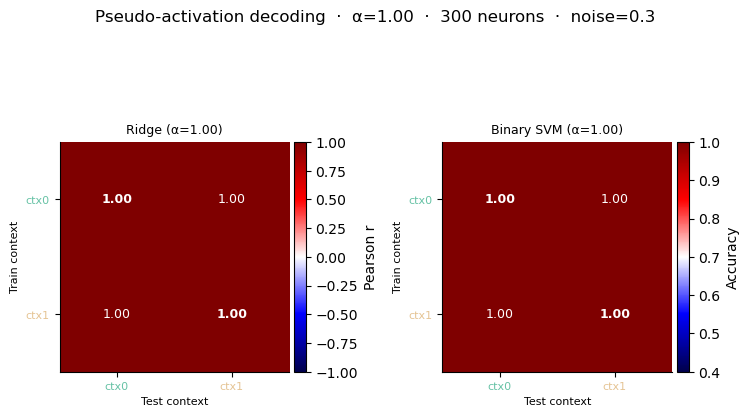

In [111]:
cell_size = 1.4
fig, axes = plt.subplots(1, 2, figsize=(cell_size * n_ctx * 2 + 2, cell_size * n_ctx + 1.5))

plot_generalisation_heatmap(
    axes[0], gm_ridge, contexts,
    vmin=-1, vmax=1, cmap="seismic",
    colorbar_label="Pearson r",
    title=f"Ridge (α={alpha:.2f})",
)
plot_generalisation_heatmap(
    axes[1], gm_svm, contexts,
    vmin=0.4, vmax=1, cmap="seismic",
    colorbar_label="Accuracy",
    title=f"Binary SVM (α={alpha:.2f})",
)
fig.suptitle(
    f"Pseudo-activation decoding  ·  α={alpha:.2f}  ·  {n_neurons} neurons  ·  "
    f"noise={noise_std}",
    y=1.04,
)
plt.tight_layout()
plt.show()

## 5b. Visualise activations

Heatmap of per-condition mean activations (conditions × neurons).
Conditions are sorted by context then by value within each context.
Neurons are sorted by their correlation with value across conditions,
so the most value-selective units appear on the left.
The geometry of the RDM should be visible by eye:
- Pure value: smooth gradient across both context blocks
- Conjunctive: smooth gradient *within* each block, scrambled across blocks
- Identity: block structure by stimulus, independent of value

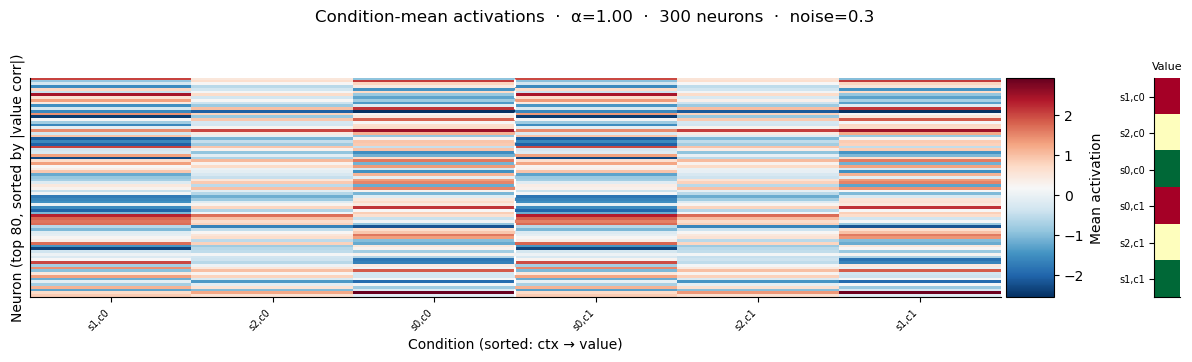

In [112]:
n_show = 80   # neurons to display

cond_means, _conds = get_condition_means(act, value_matrix)

# sort conditions: context-major, then by value within each context
cond_values = np.array([value_matrix[si, ci] for si, ci in _conds])
cond_ctx    = np.array([ci for _, ci in _conds])
cond_order  = np.lexsort((cond_values, cond_ctx))   # primary=ctx, secondary=value
sorted_means  = cond_means[cond_order]               # (K, n_neurons)
sorted_labels = [cond_labels[i] for i in cond_order]
sorted_values = cond_values[cond_order]
sorted_ctx    = cond_ctx[cond_order]

# sort neurons by abs(Pearson r with value across conditions)
corrs      = np.array([pearsonr(sorted_means[:, h], sorted_values)[0]
                       for h in range(sorted_means.shape[1])])
neuron_ord = np.argsort(np.abs(corrs))[::-1]

fig, axes = plt.subplots(
    1, 2, figsize=(12, 3.5),
    gridspec_kw={"width_ratios": [n_show, 2]},
)

ax_heat = axes[0]
im = ax_heat.imshow(
    sorted_means[:, neuron_ord[:n_show]].T,
    aspect="auto", cmap="RdBu_r",
    interpolation="nearest",
)
ax_heat.set_xlabel("Condition (sorted: ctx → value)")
ax_heat.set_ylabel(f"Neuron (top {n_show}, sorted by |value corr|)")
ax_heat.set_xticks(range(K))
ax_heat.set_xticklabels(sorted_labels, rotation=45, ha="right", fontsize=7)
ax_heat.set_yticks([])
add_colorbar(ax_heat, im, label="Mean activation")

# context boundary markers
for c in range(1, n_ctx):
    boundary = np.searchsorted(sorted_ctx, c) - 0.5
    ax_heat.axvline(boundary, color="white", lw=1.5, ls="--")

# value bar on the side
ax_val = axes[1]
ax_val.imshow(
    sorted_values[:, None], aspect="auto", cmap="RdYlGn",
    vmin=0, vmax=1, interpolation="nearest",
)
ax_val.set_xticks([])
ax_val.set_yticks(range(K))
ax_val.set_yticklabels(sorted_labels, fontsize=7)
ax_val.set_title("Value", fontsize=8)

fig.suptitle(
    f"Condition-mean activations  ·  α={alpha:.2f}  ·  {n_neurons} neurons  ·  noise={noise_std}",
    y=1.02,
)
plt.tight_layout()
plt.show()

Factorised Value      identity r=-0.193  value r=+0.908  conjunctive r=+0.000
Conjunctive           identity r=-0.039  value r=-0.281  conjunctive r=+0.768


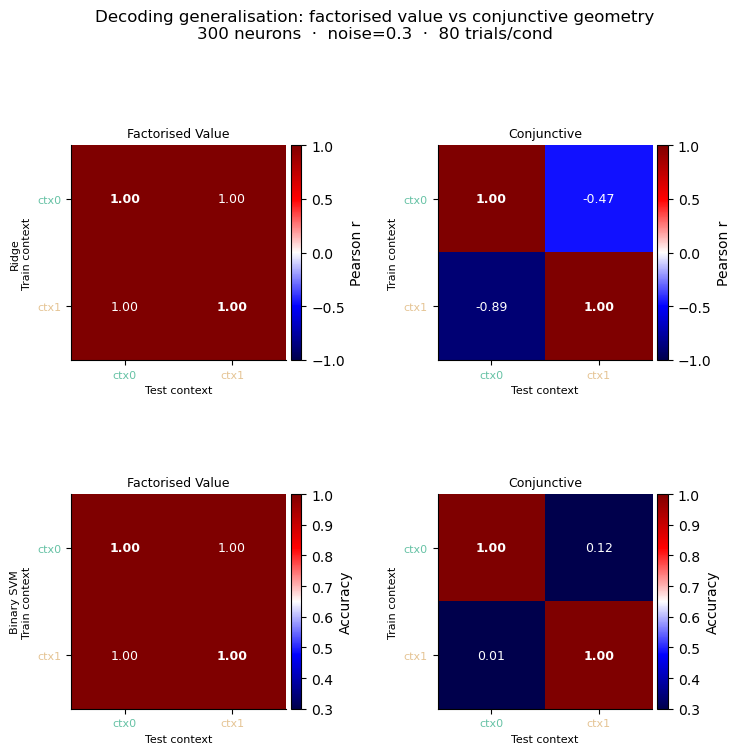

In [113]:
# ── Generalisation heatmaps: factorised value vs conjunctive coding ───────
# Run both geometries through Ridge and binary SVM and plot side by side.

_compare_rdms = {
    "Factorised Value": _norm(val_rdm),
    "Conjunctive":      _norm(conj_rdm),
}

_compare_gms = {}   # label -> {"ridge": gm, "svm": gm}
for _label, _rdm in _compare_rdms.items():
    _act = build_pseudo_act_dict(
        value_matrix, _rdm,
        n_neurons=n_neurons, n_trials_per_cond=n_trials_per_cond,
        noise_std=noise_std,
    )
    _rsa_res = rsa_compare(
        compute_neural_rdm(_act, period="stim")[0],
        {"identity": id_rdm, "value": val_rdm, "conjunctive": conj_rdm},
    )
    print(f"{_label:20s}  identity r={_rsa_res['identity']:+.3f}  "
          f"value r={_rsa_res['value']:+.3f}  "
          f"conjunctive r={_rsa_res['conjunctive']:+.3f}")

    _rw = value_decode_within(_act, period="stim", pooling=pooling,
                              value_matrix=value_matrix, n_folds=n_folds)
    _rc = value_decode_cross(_act, period="stim", pooling=pooling,
                             value_matrix=value_matrix)
    _bw = binary_value_decode_within(_act, period="stim", pooling=pooling,
                                     value_matrix=value_matrix, n_folds=n_folds)
    _bc = binary_value_decode_cross(_act, period="stim", pooling=pooling,
                                    value_matrix=value_matrix)
    _gm_svm = _bc.copy(); np.fill_diagonal(_gm_svm, _bw)
    _compare_gms[_label] = {"ridge": value_gen_matrix(_rw, _rc), "svm": _gm_svm}

# ── Plot ──────────────────────────────────────────────────────────────────
_decoders = [
    ("ridge", "Ridge",      "Pearson r",  -1,  1),
    ("svm",   "Binary SVM", "Accuracy",   0.3, 1.0),
]
cell_size = 1.4
n_models  = len(_compare_rdms)

fig, axes = plt.subplots(
    len(_decoders), n_models,
    figsize=(cell_size * n_ctx * n_models + n_models,
             cell_size * n_ctx * len(_decoders) + len(_decoders)),
    squeeze=False,
)

for row, (key, dec_label, cb_label, vmin, vmax) in enumerate(_decoders):
    for col, (model_label, gms) in enumerate(_compare_gms.items()):
        plot_generalisation_heatmap(
            axes[row, col], gms[key], contexts,
            vmin=vmin, vmax=vmax, cmap="seismic",
            colorbar_label=cb_label,
            title=model_label,
        )
        if col == 0:
            axes[row, col].set_ylabel(f"{dec_label}\nTrain context", fontsize=8)

fig.suptitle(
    f"Decoding generalisation: factorised value vs conjunctive geometry\n"
    f"{n_neurons} neurons  ·  noise={noise_std}  ·  {n_trials_per_cond} trials/cond",
    y=1.03,
)
plt.tight_layout()
plt.show()


## 6. Alpha sweep: identity → value geometry

Sweep `alpha` from 0 to 1 and record within- and cross-context decoding performance.
This shows the minimum value-geometry required to support cross-context generalisation.

In [114]:
alphas  = np.linspace(0, 1, 11)
n_seeds = 5

results = {"alpha": alphas,
           "ridge_within": np.full((len(alphas), n_seeds), np.nan),
           "ridge_cross":  np.full((len(alphas), n_seeds), np.nan),
           "svm_within":   np.full((len(alphas), n_seeds), np.nan),
           "svm_cross":    np.full((len(alphas), n_seeds), np.nan),
           "rsa_identity": np.full((len(alphas), n_seeds), np.nan),
           "rsa_value":    np.full((len(alphas), n_seeds), np.nan)}

for ai, alpha in enumerate(alphas):
    mixed = (1 - alpha) * _norm(id_rdm) + alpha * _norm(val_rdm)
    for seed in range(n_seeds):
        act = build_pseudo_act_dict(
            value_matrix, mixed,
            n_neurons=n_neurons, n_trials_per_cond=n_trials_per_cond,
            noise_std=noise_std, seed=seed,
        )

        nrdm, _ = compute_neural_rdm(act, period="stim")
        rsa     = rsa_compare(nrdm, {"identity": id_rdm, "value": val_rdm})
        results["rsa_identity"][ai, seed] = rsa["identity"]
        results["rsa_value"][ai, seed]    = rsa["value"]

        rw = value_decode_within(
            act, period="stim", pooling=pooling, value_matrix=value_matrix, n_folds=n_folds
        )
        rc = value_decode_cross(
            act, period="stim", pooling=pooling, value_matrix=value_matrix
        )
        results["ridge_within"][ai, seed] = np.nanmean(rw)
        results["ridge_cross"][ai, seed]  = np.nanmean(rc[~np.isnan(rc)])

        bw = binary_value_decode_within(
            act, period="stim", pooling=pooling, value_matrix=value_matrix, n_folds=n_folds
        )
        bc = binary_value_decode_cross(
            act, period="stim", pooling=pooling, value_matrix=value_matrix
        )
        results["svm_within"][ai, seed] = np.nanmean(bw)
        results["svm_cross"][ai, seed]  = np.nanmean(bc[~np.isnan(bc)])

    print(f"α={alpha:.2f}  ridge within={np.nanmean(results['ridge_within'][ai]):+.3f}  "
          f"cross={np.nanmean(results['ridge_cross'][ai]):+.3f}  "
          f"svm within={np.nanmean(results['svm_within'][ai]):.3f}  "
          f"cross={np.nanmean(results['svm_cross'][ai]):.3f}")

α=0.00  ridge within=+0.999  cross=-0.998  svm within=1.000  cross=0.000
α=0.10  ridge within=+0.999  cross=-0.997  svm within=1.000  cross=0.000
α=0.20  ridge within=+0.999  cross=-0.995  svm within=1.000  cross=0.000
α=0.30  ridge within=+0.999  cross=-0.988  svm within=1.000  cross=0.000
α=0.40  ridge within=+0.999  cross=-0.920  svm within=1.000  cross=0.002
α=0.50  ridge within=+0.999  cross=-0.193  svm within=1.000  cross=0.438
α=0.60  ridge within=+0.999  cross=+0.911  svm within=1.000  cross=1.000
α=0.70  ridge within=+0.999  cross=+0.985  svm within=1.000  cross=1.000
α=0.80  ridge within=+0.999  cross=+0.994  svm within=1.000  cross=1.000
α=0.90  ridge within=+0.999  cross=+0.997  svm within=1.000  cross=1.000
α=1.00  ridge within=+0.999  cross=+0.998  svm within=1.000  cross=1.000


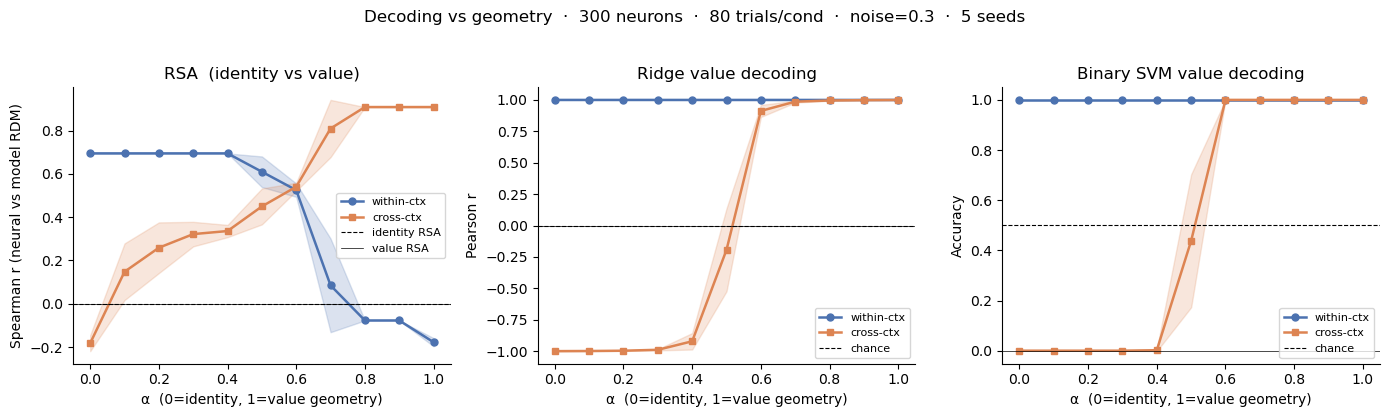

In [115]:
def _plot_sweep(ax, alphas, within, cross, ylabel, title, chance=None):
    wm = np.nanmean(within, axis=1)
    ws = np.nanstd(within,  axis=1)
    cm = np.nanmean(cross,  axis=1)
    cs = np.nanstd(cross,   axis=1)
    ax.fill_between(alphas, wm - ws, wm + ws, alpha=0.2, color="#4C72B0")
    ax.fill_between(alphas, cm - cs, cm + cs, alpha=0.2, color="#DD8452")
    ax.plot(alphas, wm, "o-", color="#4C72B0", label="within-ctx",  lw=1.8, ms=5)
    ax.plot(alphas, cm, "s-", color="#DD8452", label="cross-ctx",   lw=1.8, ms=5)
    if chance is not None:
        ax.axhline(chance, color="black", lw=0.8, ls="--", label="chance")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("α  (0=identity, 1=value geometry)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

_plot_sweep(axes[0], alphas,
            results["rsa_identity"], results["rsa_value"],
            "Spearman r (neural vs model RDM)",
            "RSA  (identity vs value)",
            chance=0)
axes[0].lines[2].set_label("identity RSA")
axes[0].lines[3].set_label("value RSA")
axes[0].legend(fontsize=8)

_plot_sweep(axes[1], alphas,
            results["ridge_within"], results["ridge_cross"],
            "Pearson r", "Ridge value decoding", chance=0)

_plot_sweep(axes[2], alphas,
            results["svm_within"],   results["svm_cross"],
            "Accuracy",  "Binary SVM value decoding", chance=0.5)

fig.suptitle(
    f"Decoding vs geometry  ·  {n_neurons} neurons  ·  "
    f"{n_trials_per_cond} trials/cond  ·  noise={noise_std}  ·  {n_seeds} seeds",
    y=1.03,
)
plt.tight_layout()
plt.show()

## 7. Stimulus-group sweep

Train the decoder on all stimuli, then test separately on anchor vs swap subsets.
This probes whether cross-context generalisation depends on the anchor stimuli providing a shared value axis.

In [ ]:
from cxval.analysis import filter_act_dict, cross_group_decode, cross_group_binary_decode

# Derive stimulus groups from the value matrix:
#   anchor: std across contexts < 0.1  (same value in every context)
#   swap:   std across contexts >= 0.1  (value differs across contexts)
_anchor_idx = [si for si in range(n_stim) if np.std(value_matrix[si, :]) < 0.1]
_swap_idx   = [si for si in range(n_stim) if np.std(value_matrix[si, :]) >= 0.1]

print(f"anchor stimuli: {_anchor_idx}  "
      f"values: {[value_matrix[si].tolist() for si in _anchor_idx]}")
print(f"swap stimuli:   {_swap_idx}  "
      f"values: {[value_matrix[si].tolist() for si in _swap_idx]}")

stim_groups = {"all": None}
if _anchor_idx:
    stim_groups["anchor"] = _anchor_idx
if _swap_idx:
    stim_groups["swap"] = _swap_idx

group_results     = {}
group_results_svm = {}

for ai, alpha in enumerate(alphas):
    mixed = (1 - alpha) * _norm(id_rdm) + alpha * _norm(val_rdm)
    act   = build_pseudo_act_dict(
        value_matrix, mixed,
        n_neurons=n_neurons, n_trials_per_cond=n_trials_per_cond,
        noise_std=noise_std, seed=0,
    )

    cgd = cross_group_decode(
        act, period="stim", pooling=pooling,
        value_matrix=value_matrix,
        train_groups={"all": None},
        test_groups=stim_groups,
        n_folds=n_folds,
    )
    group_results[alpha] = {gname: cgd[("all", gname)] for gname in stim_groups}

    cgd_bin = cross_group_binary_decode(
        act, period="stim", pooling=pooling,
        value_matrix=value_matrix,
        train_groups={"all": None},
        test_groups=stim_groups,
        n_folds=n_folds,
    )
    group_results_svm[alpha] = {gname: cgd_bin[("all", gname)] for gname in stim_groups}

print("Done.")

In [ ]:
# Identity → Conjunctive Value sweep (mirrors sweep above; same alpha axis)
# Uses the same stim_groups derived automatically in the cell above.
group_results_conj     = {}
group_results_conj_svm = {}

for ai, alpha in enumerate(alphas):
    mixed = (1 - alpha) * _norm(id_rdm) + alpha * _norm(conj_rdm)
    act   = build_pseudo_act_dict(
        value_matrix, mixed,
        n_neurons=n_neurons, n_trials_per_cond=n_trials_per_cond,
        noise_std=noise_std, seed=0,
    )

    cgd = cross_group_decode(
        act, period="stim", pooling=pooling,
        value_matrix=value_matrix,
        train_groups={"all": None},
        test_groups=stim_groups,
        n_folds=n_folds,
    )
    group_results_conj[alpha] = {gname: cgd[("all", gname)] for gname in stim_groups}

    cgd_bin = cross_group_binary_decode(
        act, period="stim", pooling=pooling,
        value_matrix=value_matrix,
        train_groups={"all": None},
        test_groups=stim_groups,
        n_folds=n_folds,
    )
    group_results_conj_svm[alpha] = {gname: cgd_bin[("all", gname)] for gname in stim_groups}

    print(f"α={alpha:.2f}  done")
print("Conjunctive sweep done.")

In [ ]:
selected_alphas_vis = [0.0, 0.25, 0.5, 0.75, 1.0]

_vis_sweeps = [
    ("identity → factorised value",  lambda a: (1-a)*_norm(id_rdm) + a*_norm(val_rdm)),
    ("identity → conjunctive value", lambda a: (1-a)*_norm(id_rdm) + a*_norm(conj_rdm)),
]

n_rows = len(_vis_sweeps)
n_cols = len(selected_alphas_vis)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.8 * n_rows))

for row, (sweep_label, rdm_fn) in enumerate(_vis_sweeps):
    for col, alpha in enumerate(selected_alphas_vis):
        ax = axes[row, col]
        rdm = rdm_fn(alpha)
        im  = ax.imshow(rdm, cmap="viridis", vmin=0, vmax=1, aspect="equal")
        ax.set_xticks(range(K))
        ax.set_xticklabels(cond_labels, fontsize=6, rotation=45, ha="right")
        ax.set_yticks(range(K))
        ax.set_yticklabels(cond_labels if col == 0 else [], fontsize=6)
        ax.set_title(f"α = {alpha:.2f}", fontsize=9)
        if col == 0:
            ax.set_ylabel(sweep_label, fontsize=8)
        if col == n_cols - 1:
            add_colorbar(ax, im, label="Dissimilarity")

fig.suptitle("Mixed RDMs across α", y=1.02)
plt.tight_layout()
plt.show()

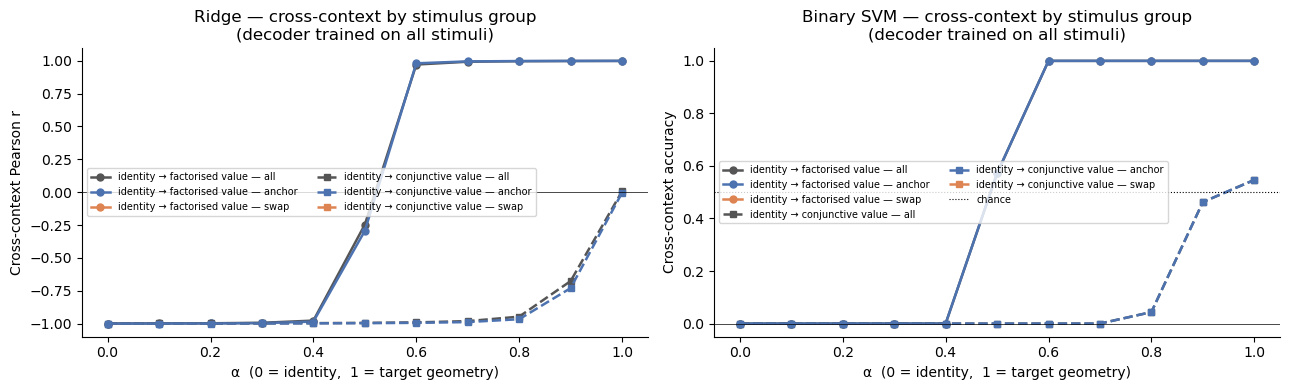

In [118]:
colors_group = {"all": "#555555", "anchor": "#4C72B0", "swap": "#DD8452"}

def _offdiag_mean(gm):
    vals = [gm[i, j] for i in range(n_ctx) for j in range(n_ctx)
            if i != j and not np.isnan(gm[i, j])]
    return np.mean(vals) if vals else np.nan

_sweeps = [
    ("identity → factorised value",  "-",  "o", group_results,     group_results_svm),
    ("identity → conjunctive value", "--", "s", group_results_conj, group_results_conj_svm),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (ylabel, title, chance, res_idx) in zip(axes, [
    ("Cross-context Pearson r", "Ridge",      None, 3),
    ("Cross-context accuracy",  "Binary SVM", 0.5,  4),
]):
    for sweep_label, ls, marker, *gres_pair in _sweeps:
        gresults = gres_pair[res_idx - 3]
        for gname in stim_groups:
            cross_vals = [_offdiag_mean(gresults[a][gname]) for a in alphas]
            ax.plot(alphas, cross_vals,
                    marker + ls, color=colors_group[gname], lw=1.8, ms=5,
                    label=f"{sweep_label} — {gname}")

    if chance is not None:
        ax.axhline(chance, color="black", lw=0.8, ls=":", label="chance")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("α  (0 = identity,  1 = target geometry)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} — cross-context by stimulus group\n(decoder trained on all stimuli)")
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC

def build_fixed_ctx0_act_dict(value_matrix, alpha, target="factorised",
                               n_neurons=300, n_trials_per_cond=80,
                               noise_std=0.3, seed=42):
    """Pseudo-activations with fixed ctx0 means across all alpha values.

    ctx0 condition means are sampled once (independent unit normals).
    ctx1 means interpolate between:
      alpha=0: identity-aligned  — mu_c1[si] = mu_c0[si]  (same stim = same rep)
      alpha=1: target-aligned
        'factorised' — mu_c1[si] = mu_c0[sj] where sj has the same value as si in ctx1
        'conjunctive' — mu_c1[si] = independent random vector
    """
    rng = np.random.default_rng(seed)
    n_stim, n_ctx = value_matrix.shape
    assert n_ctx == 2

    mu_c0 = rng.standard_normal((n_stim, n_neurons))
    mu_c1_id = mu_c0.copy()

    if target == "factorised":
        mu_c1_target = np.zeros_like(mu_c0)
        for si in range(n_stim):
            val_c1 = float(value_matrix[si, 1])
            sj = int(np.argmin(np.abs(value_matrix[:, 0] - val_c1)))
            mu_c1_target[si] = mu_c0[sj]
    elif target == "conjunctive":
        mu_c1_target = rng.standard_normal((n_stim, n_neurons))
    else:
        raise ValueError(target)

    mu_c1 = (1 - alpha) * mu_c1_id + alpha * mu_c1_target

    conditions = [(si, ci) for ci in range(n_ctx) for si in range(n_stim)]
    n_trials   = len(conditions) * n_trials_per_cond
    stim_arr   = np.empty(n_trials, dtype=int)
    ctx_arr    = np.empty(n_trials, dtype=int)
    hidden     = np.empty((n_trials, 1, n_neurons))
    mu_by_ctx  = {0: mu_c0, 1: mu_c1}

    for k, (si, ci) in enumerate(conditions):
        sl = slice(k * n_trials_per_cond, (k + 1) * n_trials_per_cond)
        stim_arr[sl] = si
        ctx_arr[sl]  = ci
        hidden[sl, 0] = mu_by_ctx[ci][si] + rng.standard_normal((n_trials_per_cond, n_neurons)) * noise_std

    return {"context": ctx_arr, "stimulus": stim_arr,
            "stim_hidden": hidden, "reward_hidden": hidden}


def fit_svm_weights(act, value_matrix, threshold=0.25):
    """Fit a linear SVM per context (high vs low, mid excluded) and return weight vectors."""
    hidden   = act["stim_hidden"][:, 0, :]
    stim_arr = act["stimulus"]
    ctx_arr  = act["context"]
    _, _n_ctx = value_matrix.shape
    weights   = np.full((_n_ctx, hidden.shape[1]), np.nan)
    for ci in range(_n_ctx):
        low_stim  = np.where(value_matrix[:, ci] <= threshold)[0]
        high_stim = np.where(value_matrix[:, ci] >= 1 - threshold)[0]
        keep_stim = np.concatenate([low_stim, high_stim])
        mask = (ctx_arr == ci) & np.isin(stim_arr, keep_stim)
        X = hidden[mask]
        y = np.array([1 if value_matrix[si, ci] >= 1 - threshold else 0
                      for si in stim_arr[mask]])
        if len(np.unique(y)) < 2:
            continue
        weights[ci] = SVC(kernel="linear", C=1.0).fit(X, y).coef_[0]
    return weights


def vec_angle(w1, w2):
    cos = np.dot(w1, w2) / (np.linalg.norm(w1) * np.linalg.norm(w2) + 1e-12)
    return float(np.degrees(np.arccos(np.clip(cos, -1, 1))))


_angle_sweeps = [
    ("identity → factorised value",  "factorised",  "-",  "o"),
    ("identity → conjunctive value", "conjunctive", "--", "s"),
]

# angle_from_0[sweep][alpha][ci]: direction angle of ctx ci SVM decoder from its identity baseline
angle_from_0 = {}
ctx_angle    = {}   # direction angle between ctx0 and ctx1 SVM decoders

for sweep_label, target, ls, marker in _angle_sweeps:
    ref_weights = fit_svm_weights(
        build_fixed_ctx0_act_dict(value_matrix, 0.0, target=target,
                                  n_neurons=n_neurons, n_trials_per_cond=n_trials_per_cond,
                                  noise_std=noise_std, seed=0),
        value_matrix,
    )

    a0_dict  = {}
    ctx_dict = {}
    for alpha in alphas:
        w_a = fit_svm_weights(
            build_fixed_ctx0_act_dict(value_matrix, alpha, target=target,
                                      n_neurons=n_neurons, n_trials_per_cond=n_trials_per_cond,
                                      noise_std=noise_std, seed=0),
            value_matrix,
        )
        a0_dict[alpha]  = {ci: vec_angle(ref_weights[ci], w_a[ci]) for ci in range(n_ctx)}
        ctx_dict[alpha] = vec_angle(w_a[0], w_a[1])

    angle_from_0[sweep_label] = a0_dict
    ctx_angle[sweep_label]    = ctx_dict
    print(f"{sweep_label}: done")
print("Done.")

In [ ]:
colors_sweep = {
    "identity → factorised value":  "#4C72B0",
    "identity → conjunctive value": "#DD8452",
}
ctx_alpha_scale = {0: 0.45, 1: 1.0}   # ctx0 lighter, ctx1 full colour

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sweep_label, target, ls, marker in _angle_sweeps:
    base_col = colors_sweep[sweep_label]
    for ci in range(n_ctx):
        col   = (*plt.matplotlib.colors.to_rgb(base_col),
                 ctx_alpha_scale[ci])   # RGBA with alpha
        vals  = [angle_from_0[sweep_label][a][ci] for a in alphas]
        lw    = 1.8 if ci == 1 else 1.2
        label = f"{sweep_label} — ctx{ci}"
        axes[0].plot(alphas, vals, marker + ls, color=col,
                     lw=lw, ms=5, label=label)

for sweep_label, target, ls, marker in _angle_sweeps:
    col = colors_sweep[sweep_label]
    axes[1].plot(alphas, [ctx_angle[sweep_label][a] for a in alphas],
                 marker + ls, color=col, lw=1.8, ms=5, label=sweep_label)

# Left panel
for ref in [0, 90, 180]:
    axes[0].axhline(ref, color="black", lw=0.6, ls=":")
axes[0].set_xlabel("α  (0 = identity,  1 = target geometry)")
axes[0].set_ylabel("Angle from identity decoder (°)")
axes[0].set_title(
    "Decoder rotation from identity baseline\n"
    "ctx0 (train) is fixed; ctx1 (test) changes with α"
)
axes[0].set_ylim(-5, 185)
axes[0].legend(fontsize=8, ncol=2)

# Right panel
for ref, lbl in [(180, "180° (anti-aligned)"), (90, "90° (orthogonal / chance)"), (0, "")]:
    axes[1].axhline(ref, color="black", lw=0.6, ls=":")
axes[1].set_xlabel("α  (0 = identity,  1 = target geometry)")
axes[1].set_ylabel("Angle between ctx0 and ctx1 decoders (°)")
axes[1].set_title(
    "Are ctx0 and ctx1 decoders aligned?\n"
    "0° = same direction (perfect generalisation),  180° = inverted"
)
axes[1].set_ylim(-5, 185)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Full generalisation heatmaps at selected alpha values

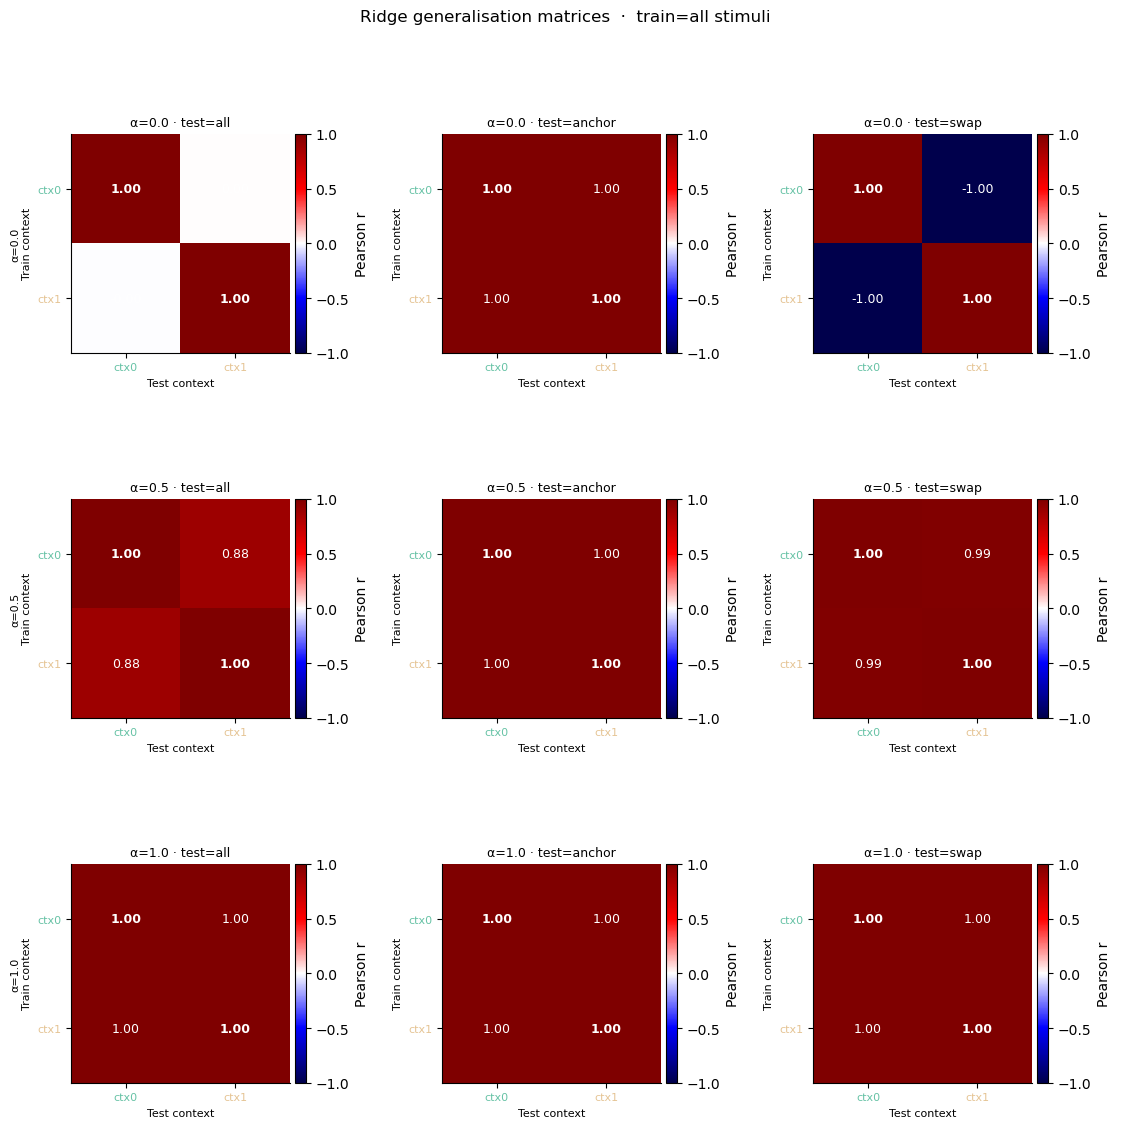

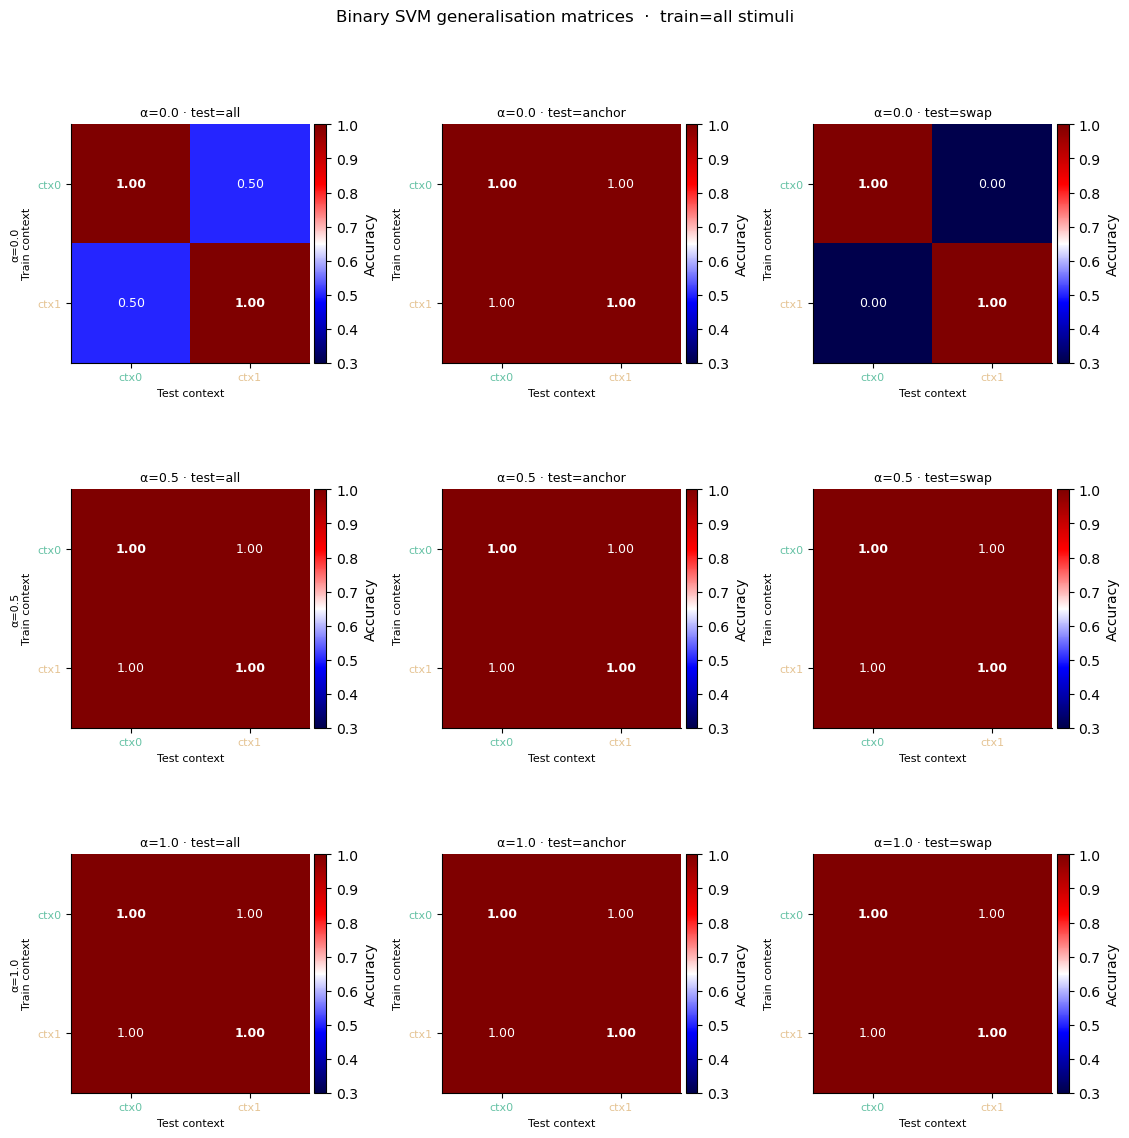

In [104]:
selected_alphas = [0.0, 0.5, 1.0]
cell_size = 1.4
n_groups  = len(stim_groups)

for decoder_label, gresults, vmin, vmax, cb_label in [
    ("Ridge",      group_results,     -1,  1,    "Pearson r"),
    ("Binary SVM", group_results_svm,  0.3, 1.0, "Accuracy"),
]:
    fig, axes = plt.subplots(
        len(selected_alphas), n_groups,
        figsize=(cell_size * n_ctx * n_groups + n_groups,
                 cell_size * n_ctx * len(selected_alphas) + len(selected_alphas)),
        squeeze=False,
    )
    for row, alpha in enumerate(selected_alphas):
        for col, gname in enumerate(stim_groups):
            gm = gresults[alpha][gname]
            plot_generalisation_heatmap(
                axes[row, col], gm, contexts,
                vmin=vmin, vmax=vmax, cmap="seismic",
                colorbar_label=cb_label,
                title=f"α={alpha:.1f} · test={gname}",
            )
            if col == 0:
                axes[row, col].set_ylabel(f"α={alpha:.1f}\nTrain context", fontsize=8)
    fig.suptitle(
        f"{decoder_label} generalisation matrices  ·  train=all stimuli",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()